### 0. 환경설정

In [1]:
import warnings, hashlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [2]:
# 데이터 로드 (ETDataset 저장소에서 직접 read)
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(URL, parse_dates=["date"]).set_index("date")
df = df.asfreq("h")          # 시간 단위 주기 명시

print("shape :", df.shape)
print("기간  :", df.index.min(), "~", df.index.max())
print("결측치 :", df.isna().sum().sum())
df.head()

shape : (17420, 7)
기간  : 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00
결측치 : 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


#### 0-1. 본인 실험 조건 배정

In [4]:
NAME = "강서영"       # TODO: 본인 이름 (예: "홍길동")

SEED   = int(hashlib.sha256(NAME.encode()).hexdigest(), 16) % 10000
COLS   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = COLS[SEED % 7]

np.random.seed(SEED); torch.manual_seed(SEED)

print(f"이름      : {NAME}")
print(f"SEED      : {SEED}")
print(f"분석 대상 : {TARGET}")

y = df[TARGET].astype(float)
print(f"\n시계열 길이: {len(y)},  결측: {y.isna().sum()}")
y.describe()

이름      : 강서영
SEED      : 5342
분석 대상 : HULL

시계열 길이: 17420,  결측: 0


count    17420.000000
mean         2.242242
std          2.042342
min         -4.756000
25%          0.737000
50%          2.210000
75%          3.684000
max         10.114000
Name: HULL, dtype: float64

### 1. 필수과제

#### 1-1. 시계열 구성 요소와 자기 상관성

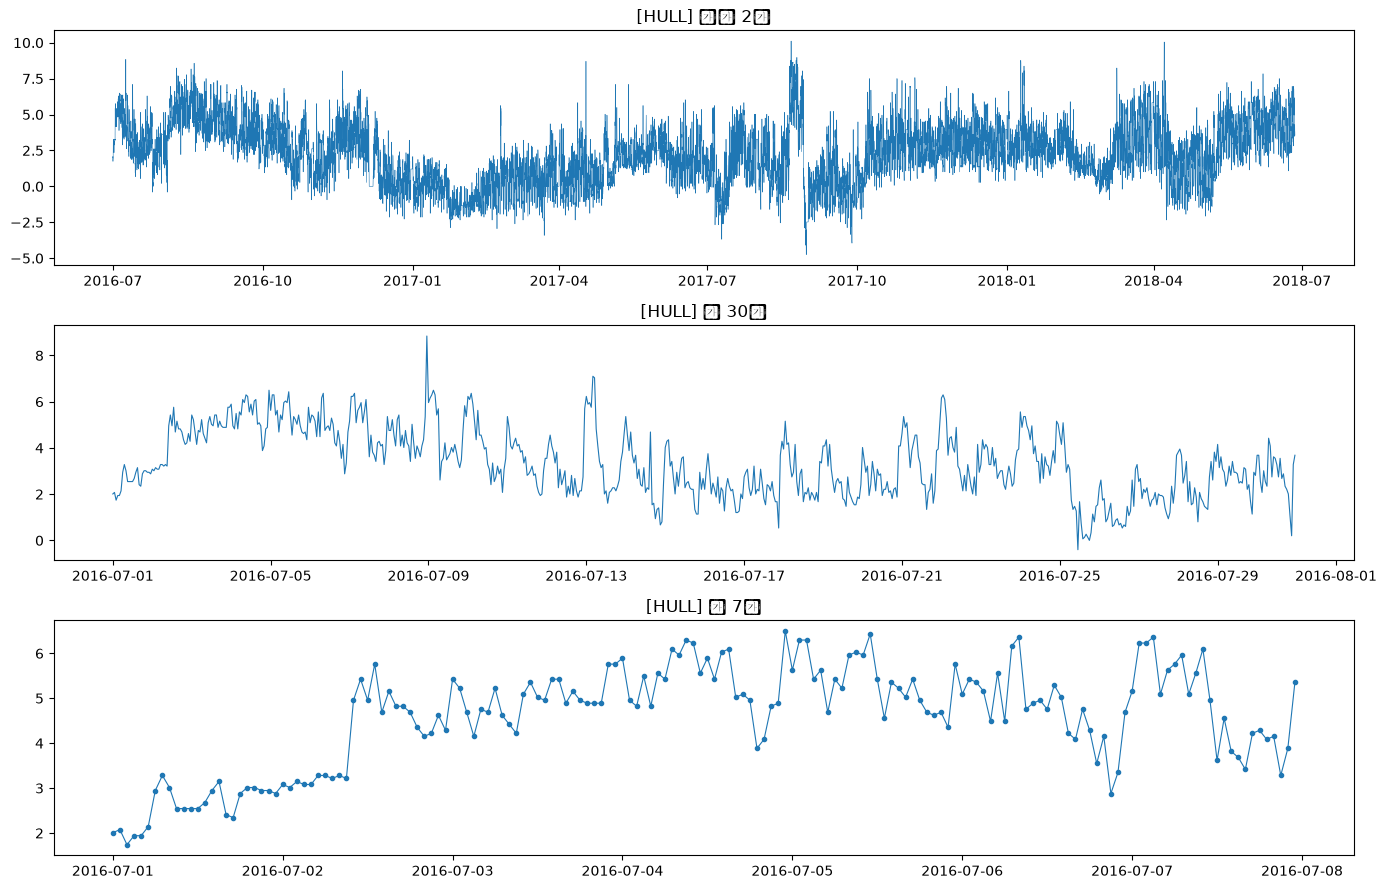

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y.index, y.values, lw=0.4);                      axes[0].set_title(f"[{TARGET}] 전체 2년")
axes[1].plot(y.index[:24*30], y.values[:24*30], lw=0.8);      axes[1].set_title(f"[{TARGET}] 첫 30일")
axes[2].plot(y.index[:24*7], y.values[:24*7], marker=".", lw=0.8); axes[2].set_title(f"[{TARGET}] 첫 7일")
plt.tight_layout(); plt.show()

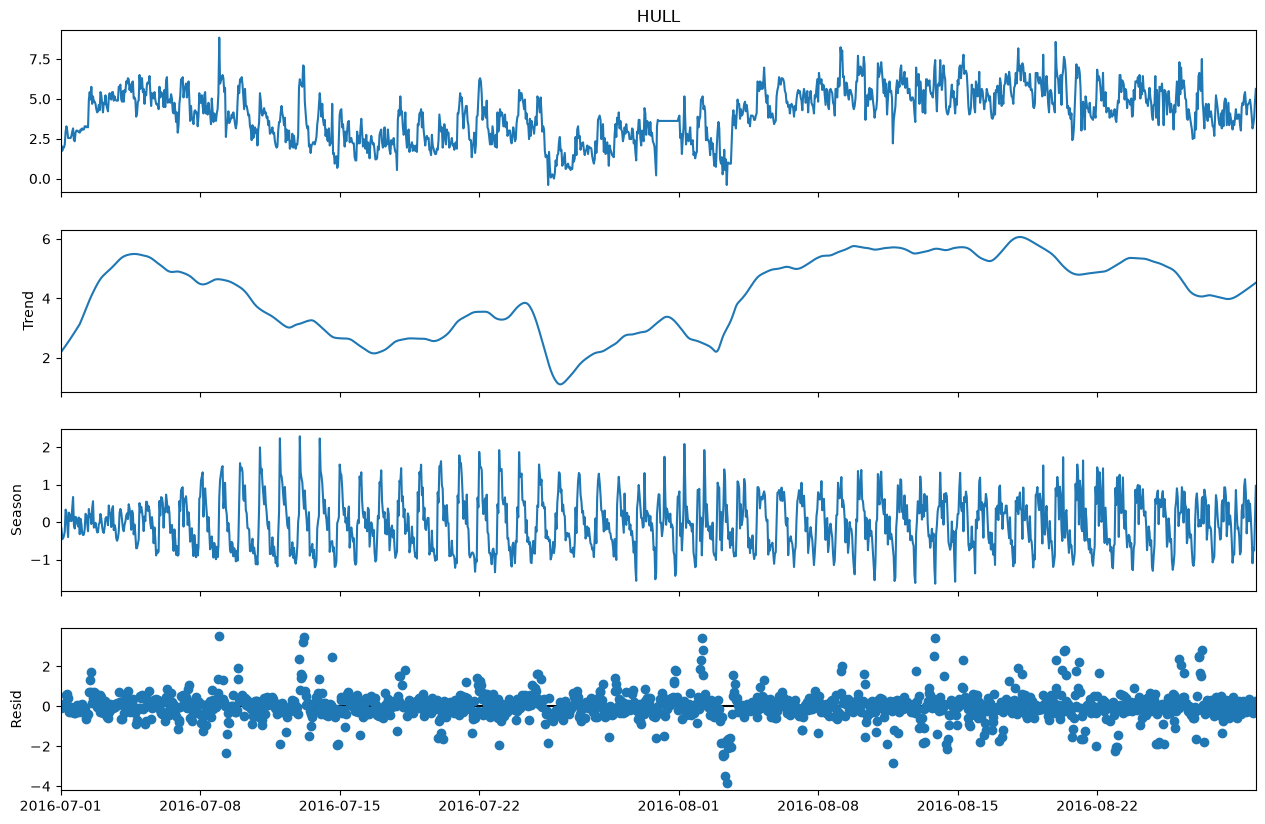

In [7]:
# 구성요소를 눈으로 분리해 봅니다.
# TODO: 이 데이터는 '시간 단위'입니다. 하루 주기를 잡으려면 period에 무엇을 넣어야 할까요?
PERIOD = 24

fig = STL(y.iloc[:24*60], period=PERIOD, robust=True).fit().plot()
fig.set_size_inches(14, 9); plt.show()

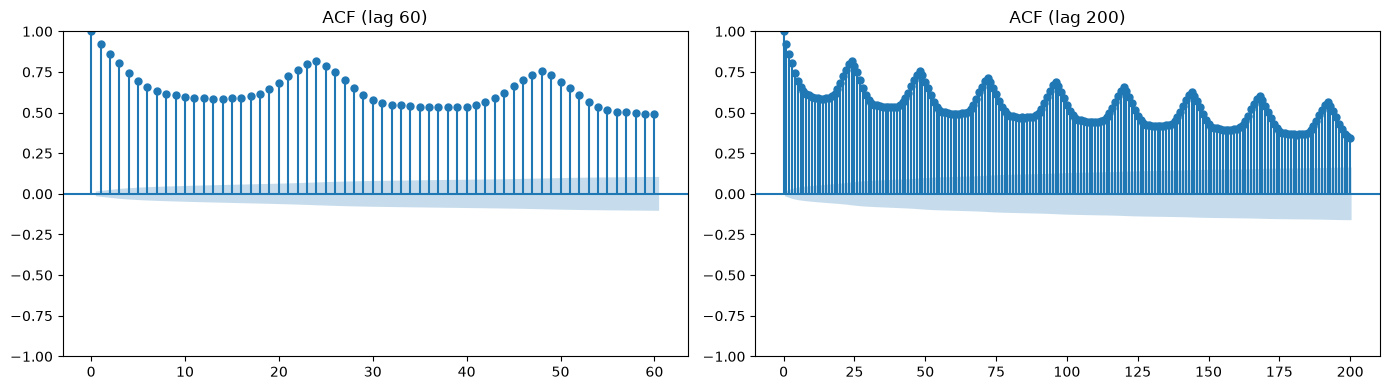

  ACF(lag=  1) = 0.920
  ACF(lag= 24) = 0.816
  ACF(lag= 48) = 0.755
  ACF(lag=168) = 0.601


In [15]:
# 자기상관성 확인 : 며칠 전 값이 현재와 얼마나 닮아 있는가
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.dropna(), lags=60,  ax=axes[0]); axes[0].set_title("ACF (lag 60)")
plot_acf(y.dropna(), lags=200, ax=axes[1]); axes[1].set_title("ACF (lag 200)")
plt.tight_layout(); plt.show()

def acf_at(s, lag):
    # ACF(k) = 시차 k만큼 떨어진 값들의 공분산 / 전체 분산
    x = np.asarray(s.dropna(), float)
    x = x - x.mean()                      # 평균을 빼서 편차로 변환

    # TODO: ACF 정의를 떠올려 분자(공분산 부분)를 완성하세요.
    #          x[lag:]는 t=lag+1..N 시점, x[:-lag]는 t=1..N-lag 시점입니다.
    numerator = (x[lag:] * x[:-lag]).sum()
    return numerator / (x * x).sum()      # 분모는 전체 분산

for lag in [1, 24, 48, 168]:
    print(f"  ACF(lag={lag:3d}) = {acf_at(y, lag):.3f}")

#### 1-2. 정상성 진단-ADF검정

In [16]:
def adf_report(series, name):
    s = pd.Series(series).dropna()
    stat, p = adfuller(s)[0], adfuller(s)[1]

    # TODO: 세션에서 배운 ADF의 귀무가설을 떠올리며 부등호를 채우세요.
    verdict = "정상 시계열" if p < 0.05 else "비정상 시계열"

    print(f"[{name:16s}] ADF={stat:9.3f}  p={p:.4f}  ->  {verdict}")
    return p

adf_report(y, "원본")

[원본              ] ADF=   -5.169  p=0.0000  ->  정상 시계열


np.float64(1.0165335326727799e-05)

> ### Q1.
> ADF 검정 결과 **원본 시계열이 "정상"** 으로 나왔을 것입니다.
> 그런데 1-1에서 그린 **ACF를 보면 lag 24, 48, 72마다 봉우리가 계속 반복**되고 있습니다.
>
> 1. "정상 시계열인데 자기상관이 강하게 남아 있다"는 것이 모순처럼 보입니다. 모순이 아닌 이유를 설명하세요.
>    (힌트: **자기상관성**과 **정상성**은 **서로 다른 특징**으로 소개되었습니다. 각각의 정의를 다시 확인해 보세요.)
: 정상성과 자기상관성은 서로 다른 개념이므로 모순이 아니다. 정상 시계열은 시간에 따라 평균, 분산 등의 통계적 특성이 일정한 시계열을 의미하며, 자기상관성은 현재 값과 과거 값 사이의 상관관계를 의미한다. 따라서 통계적 특성이 시간에 따라 일정한 정상 시계열이면서도, 인접한 시점의 값들이 서로 강하게 연관되어 높은 자기상관을 가질 수 있다.

> 2. 만약 ADF 결과만 보고 **"정상이니까 아무 처리 없이 바로 모델에 넣자"** 고 결론 내렸다면, 어떤 문제가 생길까요?
: ADF 검정은 정상성 여부만 확인하므로, 정상 시계열이라고 나왔더라도 강한 자기상관이나 계절성이 여전히 데이터에 남아있을 수 있다. 따라서 ADF 결과만 보고 바로 모델링하기보다는 ACF 등을 통해 패턴을 추가로 확인하고, 필요하다면 lag 변수나 계절 구조 등을 모델에 반영해야 한다.

#### 1-3. 차분

In [17]:
y_diff1 = y.diff()          # 1차 차분

# TODO: 하루 주기를 제거하는 계절 차분을 만드세요. (힌트: .diff(?) )
y_seas  = y.diff(24)

print("=" * 60)
adf_report(y,       "원본")
adf_report(y_diff1, "1차 차분")
adf_report(y_seas,  "계절 차분(lag 24)")
print("=" * 60)

[원본              ] ADF=   -5.169  p=0.0000  ->  정상 시계열
[1차 차분           ] ADF=  -29.469  p=0.0000  ->  정상 시계열
[계절 차분(lag 24)   ] ADF=  -21.652  p=0.0000  ->  정상 시계열


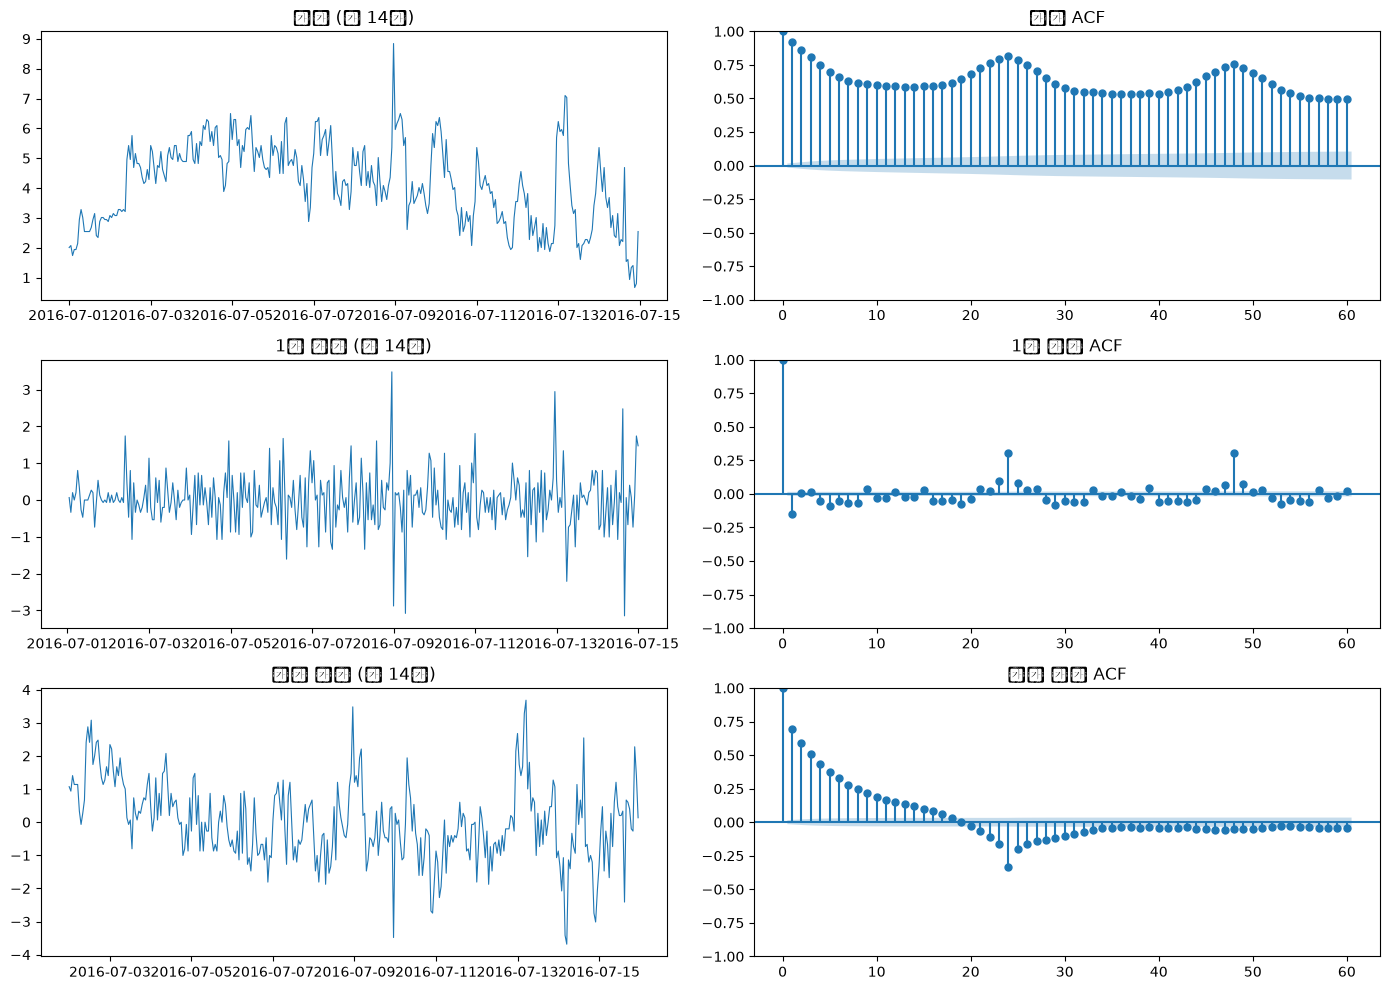

  원본           ACF(24) =   0.816
  1차 차분        ACF(24) =   0.302
  계절 차분        ACF(24) =  -0.336


In [18]:
# '차분 전 / 후' ACF를 비교합니다.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, (s, name) in enumerate([(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]):
    s_ = s.dropna()
    axes[i, 0].plot(s_.index[:24*14], s_.values[:24*14], lw=0.8); axes[i, 0].set_title(f"{name} (앞 14일)")
    plot_acf(s_, lags=60, ax=axes[i, 1]);                          axes[i, 1].set_title(f"{name} ACF")
plt.tight_layout(); plt.show()

for s, name in [(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]:
    print(f"  {name:12s} ACF(24) = {acf_at(s, 24):7.3f}")

> ### Q2.
> 1. **계절 차분 후** ACF의 lag 24 값이 0 근처가 아니라 **음수로 크게** 나왔을 것입니다. 세션에서 차분의 목적은 "정상 시계열로 바꾸는 것"이었는데, 이 결과는 차분이 잘 된 것이라고 볼 수 있나요? 근거와 함께 쓰세요.
: 원본데이터를 확인해보면 하루주기로 계절성을 보이는 것을 알 수 있다. 하지만 계절성이 존재한다고 해서 반드시 계절차분이 필요한 것은 아니다. 정상성은 평균, 분산, 자기상관 구조가 시간에 따라 안정적인지를 의미하고 계절성은 일정한 주기의 패턴이 반복되는지를 의미하므로 서로 다른 개념이다. 따라서 정상 시계열에서도 강한 계절성이 존재할 수 있다. 원본이 이미 정상성을 만족하는데 계절 차분 후 lag24에서 강한 음의 자기상관이 새롭게 발생했다면, 불필요한 차분으로 새로운 의존구조를 만든 과차분의 가능성이 있으므로 차분이 잘 되었다고 보기 어렵다.

> 2. 위 결과를 종합해, 1-7에서 사용할 SARIMA의 **차분 차수 d 와 계절 차분 차수 D** 를 결정하고 근거를 서술하세요.
: 원본 시계열이 ADF 검정에서 이미 정상성을 만족하지만 1차 차분 후에도 정상성을 유지하면서 ACF 값이 0.302로 감소하여 장기적인 자기상관이 완화되었으므로 d=1로 설정한다. 반면 원본에서 24시간 주기의 계절성은 존재하지만, 계절 차분 후 lag24에서 강한 음의 자기상관이 새롭게 나타나 과차분 가능성이 확인되었으므로 D=0으로 설정한다.

#### 1-4. ACF/PACF 차수 결정

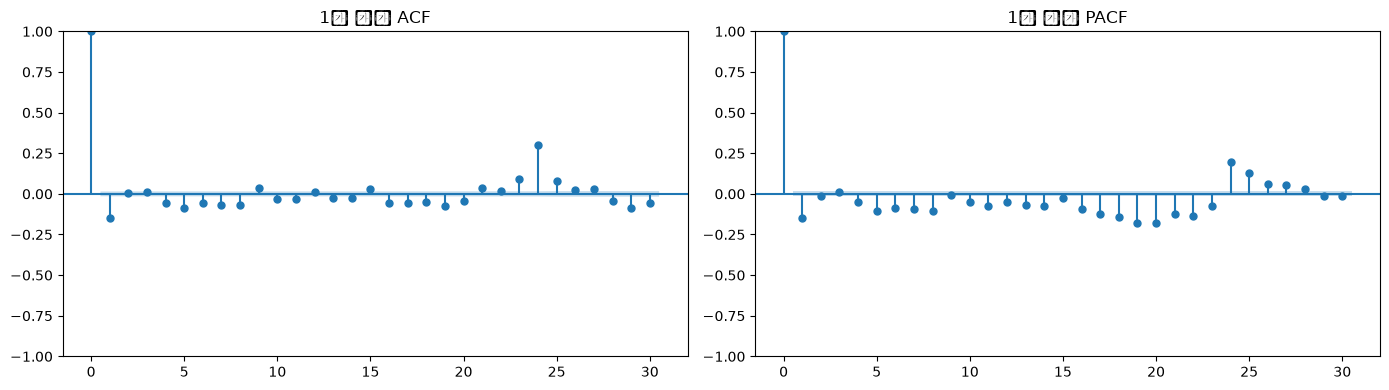

In [20]:
s_ = y_diff1.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_,  lags=30, ax=axes[0]); axes[0].set_title("1차 차분 ACF")
plot_pacf(s_, lags=30, ax=axes[1]); axes[1].set_title("1차 차분 PACF")
plt.tight_layout(); plt.show()

In [26]:
# TODO: Q2의 판단 결과와 위 ACF/PACF 그림을 반영하세요.
P_ORDER  = 1          # 비계절 AR 차수 p
D_ORDER  = 1         # 차분 차수 d
Q_ORDER  = 1          # 비계절 MA 차수 q
SEASONAL = (1, 0, 1, 24) # (P, D, Q, m)

print(f"SARIMA{(P_ORDER, D_ORDER, Q_ORDER)}{SEASONAL}")

SARIMA(1, 1, 1)(1, 0, 1, 24)


#### 1.5 평가 프로토콜 설계-Time-Based Split

In [21]:
n = len(y)

# TODO: 시간순으로 70% / 80% 지점의 인덱스를 계산하세요.
i_train = int(n * 0.7)
i_val   = int(n * 0.8)

train, val, test = y[:i_train], y[i_train:i_val], y[i_val:]
L, H, M = 168, 24, 24        # lookback, horizon, 계절주기

for nm, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:6s} {len(s):6d}  ({s.index.min().date()} ~ {s.index.max().date()})")

train   12194  (2016-07-01 ~ 2017-11-21)
val      1742  (2017-11-21 ~ 2018-02-01)
test     3484  (2018-02-01 ~ 2018-06-26)


In [22]:
# 모든 모델이 공유할 평가 지점(origin) 30개
N_ORIGIN = 30

# TODO: origin끼리 예측 구간(H시간)이 겹치지 않게 하려면 간격을 얼마로 둬야 할까요?
cand    = np.arange(i_val, n - H, 24)
origins = cand[np.linspace(0, len(cand) - 1, N_ORIGIN).astype(int)]
Y_TRUE  = np.stack([y.values[t:t + H] for t in origins])   # (30, 24) 정답

print("origin 개수:", len(origins), "| 정답 행렬:", Y_TRUE.shape)
print("첫 origin :", y.index[origins[0]], "/ 끝 origin :", y.index[origins[-1]])

origin 개수: 30 | 정답 행렬: (30, 24)
첫 origin : 2018-02-01 16:00:00 / 끝 origin : 2018-06-25 16:00:00


In [23]:
def score(name, pred):
    e    = Y_TRUE - pred
    mae  = np.mean(np.abs(e))

    # TODO: 세션의 정의를 보고 RMSE를 완성하세요.
    rmse = np.sqrt(np.mean(e**2))

    nz   = np.abs(Y_TRUE) > 1e-6                       # 0 나눗셈 방지
    mape = np.mean(np.abs(e[nz] / Y_TRUE[nz])) * 100
    return dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
excluded = (1 - (np.abs(Y_TRUE) > 1e-6).mean()) * 100
print(f"MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = {excluded:.2f}%")
print(f"정답값 중 절대값 0.5 미만 비율          = {(np.abs(Y_TRUE) < 0.5).mean()*100:.2f}%")
print(f"정답값 중 음수 비율                     = {(Y_TRUE < 0).mean()*100:.2f}%   (최솟값 {Y_TRUE.min():.3f})")

MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = 0.69%
정답값 중 절대값 0.5 미만 비율          = 5.28%
정답값 중 음수 비율                     = 6.39%   (최솟값 -1.674)


#### 1-6. 베이스라인 만들기

In [24]:
pred_naive  = np.stack([np.repeat(y.values[t - 1], H) for t in origins])

# TODO: Seasonal Naive를 구현하세요. 24시간 전 같은 시각부터 H시간을 그대로 가져옵니다.
pred_snaive = np.stack([y.values[t - M : t - M + H] for t in origins])

results.append(score("Naive",         pred_naive))
results.append(score("SeasonalNaive", pred_snaive))
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,MAPE
model,,,
Naive,1.2039,1.5703,62.4669
SeasonalNaive,0.8383,1.1667,43.6922


> ### Q3.
> 1. `Naive` 와 `SeasonalNaive` 의 성능 차이로부터 이 데이터의 어떤 성질을 알 수 있나요?
>    단, 1-1의 ACF 값을 다시 보면 **ACF(1)이 ACF(24)보다 큽니다.** "직전 값이 가장 닮았다"는 뜻인데 왜 `Naive`가 졌을까요?
>    (힌트: 이 과제는 1시간 뒤가 아니라 **24시간치를 한 번에** 예측합니다. `Naive`는 24시간 동안 무슨 값을 내놓나요?)
: SeasonalNaive가 Naive보다 좋은 성능을 보인 것으로 보아 이 데이터에는 24시간 주기의 계절성이 강하게 존재하며, 이를 활용하는 것이 24시간 예측에 효과적임을 알 수 있다. ACF(1)이 ACF(24)보다 크더라도 이는 한 시점 간의 상관관계가 더 강하다는 의미일 뿐이다. Naive는 직전 값 하나를 향후 24시간 동안 동일하게 사용하기 때문에 시간대별 변화를 반영하지 못하는 반면, SeasonalNaive는 24시간 전의 시간대별 패턴을 활용하므로 24시간 전체 예측에서 더 좋은 성능을 보일 수 있다.

> 2. 앞으로 만들 SARIMA / LSTM / DLinear 가 **최소한 어떤 수치를 넘어야** 의미 있는 모델일까요? 구체적인 숫자로 답하세요.
>
> *(이 질문의 답은 1-10에서 모델 성능을 해석할 때 기준선으로 계속 사용됩니다.)*
: 가장 성능이 좋은 baseline인 SeasonalNaive를 기준으로 삼아야한다. 따라서 SARIMA, LSTM, DLinear 는 최소한 MAE 0.8383, RMSE 1.1667, MAPE 43.6922 보다 낮은 값을 보여야 단순한 계절 반복 예측보다 의미있는 모델이라고 볼 수 있다.

#### 1-7. 모델 A-SARIMA

In [27]:
WINDOW = 1000
t0, preds = time.time(), []

for i, t in enumerate(origins):
    # TODO: origin t 직전 WINDOW 시간만 잘라내세요. (미래가 절대 포함되면 안 됩니다)
    hist = y.values[t-WINDOW : t]

    m = SARIMAX(hist, order=(P_ORDER, D_ORDER, Q_ORDER), seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # TODO: 앞으로 H시간을 예측하세요.
    preds.append(m.forecast(H))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(origins)}  ({time.time()-t0:.0f}s)")

pred_sarima = np.stack(preds)
results.append(score("SARIMA", pred_sarima))
print(f"\n총 소요 {time.time()-t0:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

  10/30  (7s)


c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  20/30  (22s)
  30/30  (39s)

총 소요 39초


,MAE,RMSE,MAPE
model,,,
Naive,1.2039,1.5703,62.4669
SeasonalNaive,0.8383,1.1667,43.6922
SARIMA,0.7175,1.0446,43.7868


#### 1-8. 모델 B-LSTM

In [28]:
# TODO: 평균과 표준편차를 어느 구간에서 계산해야 할까요?
mu, sd = train.mean(), train.std()

ys = ((y - mu) / sd).values.astype("float32")
print(f"정규화 기준  mu={mu:.4f}, sd={sd:.4f}")

def make_windows(lo, hi, L_=None):
    """[lo, hi) 구간에서 (입력 L, 정답 H) 쌍을 슬라이딩으로 생성"""
    L_ = L_ or L
    X, Y = [], []
    for t in range(lo + L_, hi - H + 1):
        X.append(ys[t - L_ : t]); Y.append(ys[t : t + H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_tr, Y_tr = make_windows(0, i_train)
X_va, Y_va = make_windows(i_train, i_val)
X_te       = torch.tensor(np.stack([ys[t - L : t] for t in origins]))

print("train:", X_tr.shape, "| val:", X_va.shape, "| test:", X_te.shape)

정규화 기준  mu=1.9570, sd=2.1131
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])


In [29]:
# 학습 곡선 보는 법
#   - train / val이 나란히 감소 후 수평   -> 적절
#   - train은 계속 감소하는데 val이 반등  -> 과적합
#   - 둘 다 높은 채로 안 내려감           -> 과소적합 (epoch/lr 조정 필요)

def train_model(model, X_tr, Y_tr, X_va, Y_va, epochs=15, bs=64, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt, lossf = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=bs, shuffle=True)

    history, best_val, best_state = {"train": [], "val": []}, float("inf"), None
    for ep in range(epochs):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(X_va.to(DEVICE)), Y_va.to(DEVICE)).item()
        history["train"].append(total / len(X_tr)); history["val"].append(vl)

        # TODO: train loss가 아니라 val loss가 가장 낮았던 시점의 모델을 저장해야 합니다.
        #          어떤 조건일 때 이 epoch의 모델을 best_state로 저장해야 할까요?
        if vl < best_val:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  [{tag}] epoch {ep+1:3d}  train={history['train'][-1]:.5f}  val={vl:.5f}")
    model.load_state_dict(best_state)
    print(f"  [{tag}] best val loss = {best_val:.5f}  |  파라미터 {sum(p.numel() for p in model.parameters()):,d}")
    return model, history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(DEVICE)).cpu().numpy() * sd + mu


def plot_curve(hist, title):
    plt.figure(figsize=(7, 3.5))
    plt.plot(hist["train"], label="train", marker="o", ms=3)
    plt.plot(hist["val"],   label="val",   marker="s", ms=3)
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

  [LSTM] epoch   5  train=0.27214  val=0.22333
  [LSTM] epoch  10  train=0.23294  val=0.19447
  [LSTM] epoch  15  train=0.21683  val=0.20323
  [LSTM] best val loss = 0.19447  |  파라미터 18,712


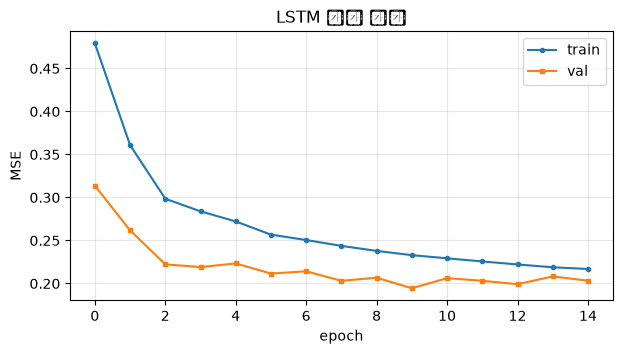

,MAE,RMSE,MAPE
model,,,
Naive,1.2039,1.5703,62.4669
SeasonalNaive,0.8383,1.1667,43.6922
SARIMA,0.7175,1.0446,43.7868
LSTM,0.8144,1.0856,47.6097


In [30]:
class LSTMForecast(nn.Module):
    def __init__(self, H, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, H)

    def forward(self, x):                 # x: (B, L)
        out, _ = self.lstm(x.unsqueeze(-1))   # (B, L, hidden)
        # TODO: 168개 시점의 은닉 상태 중 예측에 사용할 것은 무엇일까요?
        #       (힌트: RNN 구조 그림에서 마지막 시점의 은닉 상태)
        return self.fc(out[:, -1])

torch.manual_seed(SEED)
t0 = time.time()
model_lstm, hist_lstm = train_model(LSTMForecast(H), X_tr, Y_tr, X_va, Y_va, tag="LSTM")
t_lstm = time.time() - t0
results.append(score("LSTM", predict(model_lstm, X_te)))
plot_curve(hist_lstm, "LSTM 학습 곡선")
pd.DataFrame(results).set_index("model").round(4)

#### 1-9. 모델C-LTSF-DLinear

  [DLinear] epoch   5  train=0.24125  val=0.18780
  [DLinear] epoch  10  train=0.24291  val=0.18035
  [DLinear] epoch  15  train=0.24184  val=0.18369
  [DLinear] best val loss = 0.18031  |  파라미터 8,112


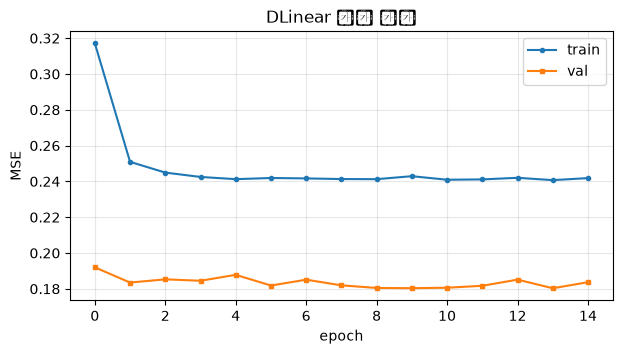

DLinear 학습 시간 4초


,MAE,RMSE,MAPE
model,,,
Naive,1.2039,1.5703,62.4669
SeasonalNaive,0.8383,1.1667,43.6922
SARIMA,0.7175,1.0446,43.7868
LSTM,0.8144,1.0856,47.6097
DLinear,0.6962,0.9638,44.8267


In [31]:
class DLinear(nn.Module):
    def __init__(self, L, H, kernel=25):   # kernel은 반드시 홀수 (짝수면 출력 길이가 1 늘어남)
        super().__init__()
        self.kernel = kernel
        self.lin_trend     = nn.Linear(L, H)   # 추세 성분용
        self.lin_remainder = nn.Linear(L, H)   # 잔차 성분용

    def series_decomp(self, x):
        """(1) 이동평균으로 Trend를 뽑고, 원본에서 빼서 Remainder를 얻습니다."""
        pad_len = self.kernel // 2
        pad   = torch.cat([x[:, :1].repeat(1, pad_len), x, x[:, -1:].repeat(1, pad_len)], dim=1)
        trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1)

        # TODO: Remainder 성분은 어떻게 구하나요?
        remainder = x - trend
        return remainder, trend

    def forward(self, x):
        remainder, trend = self.series_decomp(x)
        # TODO: (3)단계입니다. 두 Linear의 출력을 어떻게 결합하나요?
        return self.lin_remainder(remainder) + self.lin_trend(trend)

torch.manual_seed(SEED)
t0 = time.time()
model_dl, hist_dl = train_model(DLinear(L, H), X_tr, Y_tr, X_va, Y_va, tag="DLinear")
t_dl = time.time() - t0
results.append(score("DLinear", predict(model_dl, X_te)))
plot_curve(hist_dl, "DLinear 학습 곡선")
print(f"DLinear 학습 시간 {t_dl:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

#### 1-10. 성능 비교 및 해석

,MAE,RMSE,MAPE
model,,,
DLinear,0.6962,0.9638,44.8267
SARIMA,0.7175,1.0446,43.7868
LSTM,0.8144,1.0856,47.6097
SeasonalNaive,0.8383,1.1667,43.6922
Naive,1.2039,1.5703,62.4669


,MAE,개선율(%)
model,,
DLinear,0.6962,16.95
SARIMA,0.7175,14.41
LSTM,0.8144,2.85
SeasonalNaive,0.8383,0.00
Naive,1.2039,-43.61


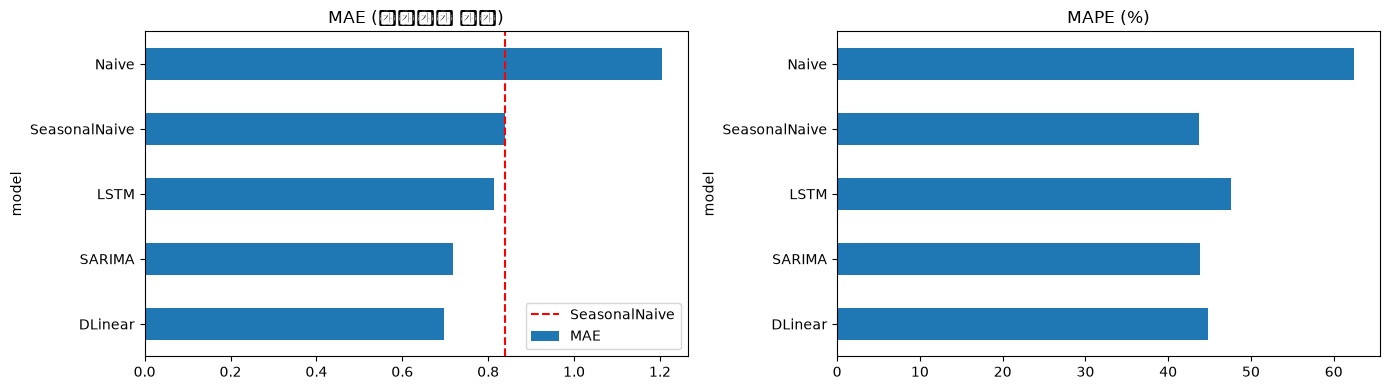

In [32]:
res = pd.DataFrame(results).set_index("model").sort_values("MAE").round(4)
display(res)

base = res.loc["SeasonalNaive", "MAE"]
res["개선율(%)"] = ((base - res["MAE"]) / base * 100).round(2)   # 베이스라인 대비
display(res[["MAE", "개선율(%)"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
res["MAE"].plot(kind="barh", ax=axes[0], title="MAE (낮을수록 좋음)")
axes[0].axvline(base, color="red", ls="--", label="SeasonalNaive"); axes[0].legend()
res["MAPE"].plot(kind="barh", ax=axes[1], title="MAPE (%)")
plt.tight_layout(); plt.show()

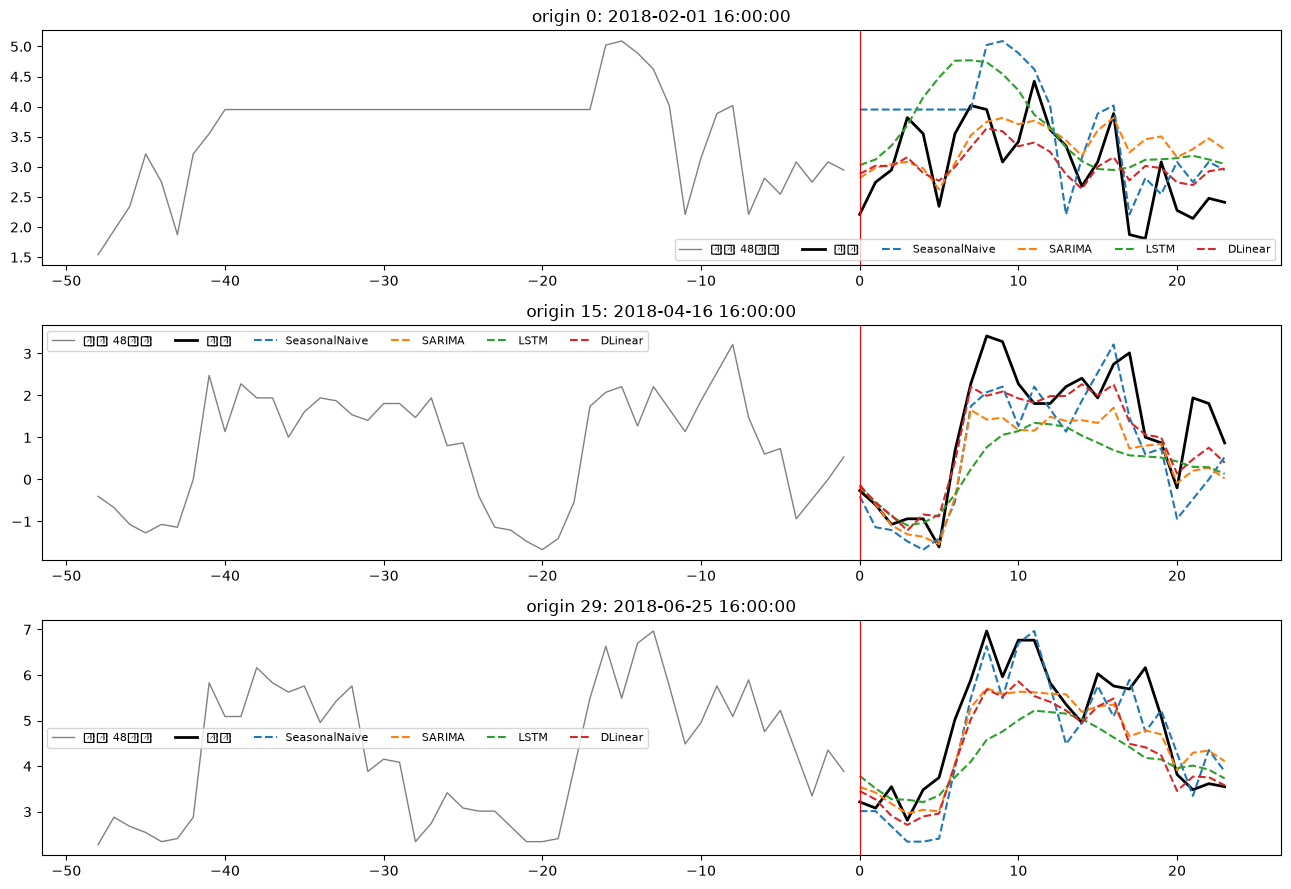

In [33]:
pred_dl, pred_lstm = predict(model_dl, X_te), predict(model_lstm, X_te)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, k in zip(axes, [0, len(origins)//2, len(origins)-1]):
    t = origins[k]
    ax.plot(range(-48, 0), y.values[t-48:t], color="gray", lw=1, label="과거 48시간")
    ax.plot(range(H), Y_TRUE[k],      "k-", lw=2, label="실제")
    ax.plot(range(H), pred_snaive[k], "--", label="SeasonalNaive")
    ax.plot(range(H), pred_sarima[k], "--", label="SARIMA")
    ax.plot(range(H), pred_lstm[k],   "--", label="LSTM")
    ax.plot(range(H), pred_dl[k],     "--", label="DLinear")
    ax.axvline(0, color="red", lw=.8); ax.set_title(f"origin {k}: {y.index[t]}")
    ax.legend(fontsize=8, ncol=6)
plt.tight_layout(); plt.show()

> ### Q4. 왜 이러한 결과가 나왔는가?
> 순위를 나열하지 말고, **데이터의 성질과 각 모델의 구조를 연결**해서 설명하세요.
: 이 데이터는 ACF에서 확인했듯이 24시간 주기의 계절성이 강하고, 시간에 따른 추세와 반복적인 패턴이 비교적 뚜렷한 시계열이다. DLinear는 입력 시계열을 이동평균을 이용해 추세(trend)와 잔차(remainder)로 분해한 뒤 각각을 선형적으로 학습하므로 이러한 비교적 규칙적인 구조를 효과적으로 학습할 수 있었고, 그 결과 SeasonalNaive보다 MAE가 약 16.95% 개선되었다. SARIMA 역시 자기상관과 24시간 계절성을 AR/MA 및 계절항으로 직접 모델링하기 때문에 좋은 성능을 보였다.

> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?
> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.
> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)
: 예측 곡선을 보면 모델 간 성능 차이는 주로 급격한 변동을 얼마나 잘 따라가는지와 장기 예측에서 실제 패턴을 얼마나 유지하는지에서 발생했다. 실제값이 급격하게 상승 및 하락하는 구간에서는 SARIMA, LSTM, DLinear 모두 실제 변동폭보다 완만하게 예측하는 경향이 있어 큰 오차가 발생하였다. 이 상황에서는 SeasonlaNaive가 다른 모델에 비해 유리하였다. 반면 비교적 평탄하거나 완만하게 변화하는 구간에서는 DLinear나 SARIMA의 예측값들이 실제값의 수준과 방향을 비교적 안정적으로 따라갔다고 볼 수 있다. 또한 예측 시점에서 멀어질수록 학습 기반 모델의 예측이 상대적으로 평활해지면서 실제값의 세부적인 변동을 놓치는 모습을 볼 수 있었다. 해당 구간에서는 DLinear가 근소한 차이로 유리함을 볼 수 있다. 

> ### Q6. 예상과 다른 결과가 나왔다면 그 원인은 무엇인가?
> 1. 실험 전 예상과 실제 결과가 달랐던 지점을 하나 이상 쓰고 원인을 분석하세요.
: LSTM과 같은 딥러닝 모델의 예측성능이 좋을 것이라고 예상하였으나 오히려 SeasonalNaive가 성능이 더 좋게 나왔다. 그 원인은 데이터에 24시간 주기의 반복적인 계절성이 강하게 존재하여, 복잡한 비선형 관계를 학습하는 LSTM보다 단순히 24시간 전 동일 시점의 값을 사용하는 SeasonalNaive가 이러한 패턴을 효과적으로 활용했기 때문으로 판단된다.

> 2. **MAPE 값이 유독 크게 나왔을 수 있습니다.** 1-5에서 출력한 통계(0에 가까운 값의 비율, **음수 비율**)와 연결해 원인을 설명하고, 세션에서 배운 세 지표 중 **이 데이터에서는 무엇을 주로 봐야 하는지** 근거와 함께 제시하세요.
>    (힌트: MAPE는 오차를 실제값으로 나눕니다. 실제값이 **음수**이면 그 결과를 "오차율"이라고 부를 수 있을까요?)
: MAPE가 유독 크게 나타난 이유는 실제값이 0에 가까운 데이터와 음수 데이터가 포함되어 있기 때문이다. MAPE는 오차를 실제값으로 나누어 계산하므로 실제값이 0에 가까울수록 작은 절대오차도 매우 큰 비율오차로 계산된다. 실제로 정답값 중 절대값이 0.5미만인 값이 5.28% 존재하여 MAPE가 크게 증가할 수 있다. 또한 음수값도 6.39% 존재하는데, MAPE는 본래 실제값 대비 상대적인 오차율을 해석하기 위한 지표이므로 음수값이 존재하는 데이터에서는 오차율이라는 해석 자체가 직관적이지 않다. 따라서 이 데이터에서는 MAPE보다 MAE와 RMSE를 중심으로 모델 성능을 평가하는 것이 적절하다.

### 2. 심화 A. 검증 전략 비교

Time-Based Split (origin 1개) MAE = 0.4930
Walk-Forward     (origin 30개) MAE = 0.6962
origin별 MAE  최소 0.2409 / 최대 1.8742 / 표준편차 0.3017


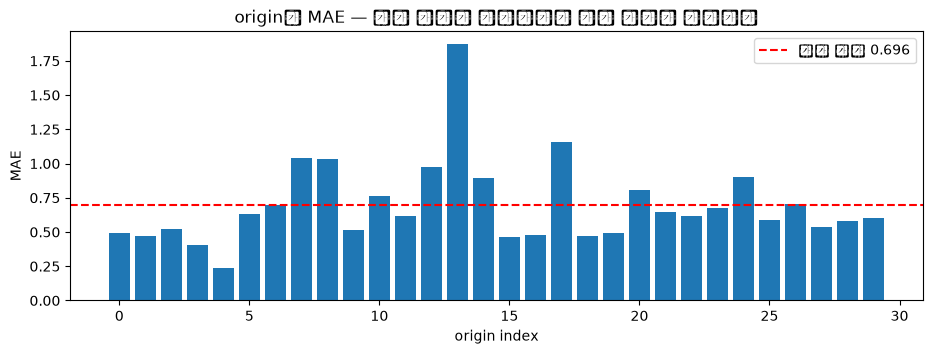

In [34]:
p = predict(model_dl, X_te)
per_origin = np.abs(Y_TRUE - p).mean(axis=1)

# TODO: "Time-Based Split"은 test 구간에서 origin을 딱 1개(맨 처음)만 골라 평가하는 방식입니다.
#       per_origin 배열에서 그 origin의 결과는 어떻게 가져와야 할까요?
single_mae = per_origin[0]

print(f"Time-Based Split (origin 1개) MAE = {single_mae:.4f}")
print(f"Walk-Forward     (origin 30개) MAE = {per_origin.mean():.4f}")
print(f"origin별 MAE  최소 {per_origin.min():.4f} / 최대 {per_origin.max():.4f} / 표준편차 {per_origin.std():.4f}")

plt.figure(figsize=(11, 3.5))
plt.bar(range(len(per_origin)), per_origin)
plt.axhline(per_origin.mean(), color="red", ls="--", label=f"전체 평균 {per_origin.mean():.3f}")
plt.xlabel("origin index"); plt.ylabel("MAE"); plt.legend()
plt.title("origin별 MAE — 어느 구간을 고르느냐에 따라 결론이 달라진다")
plt.show()

### 2. 심화 B.lookback 길이 실험

In [35]:
# TODO: 서로 다른 lookback 길이를 실험해 보세요. (예: 24, 96, 168, 336)
LOOKBACKS = [24, 96, 168, 336]

rows = []
for L_try in LOOKBACKS:
    Xa, Ya = make_windows(0, i_train, L_try)
    Xb, Yb = make_windows(i_train, i_val, L_try)
    Xc     = torch.tensor(np.stack([ys[t - L_try : t] for t in origins]))

    torch.manual_seed(SEED)
    m, _ = train_model(DLinear(L_try, H), Xa, Ya, Xb, Yb, epochs=15, tag=f"L={L_try}")
    s = score(f"L{L_try}", predict(m, Xc))
    rows.append({"lookback": L_try, "MAE": s["MAE"], "RMSE": s["RMSE"]})

pd.DataFrame(rows).set_index("lookback").round(4)

  [L=24] epoch   5  train=0.27269  val=0.20633
  [L=24] epoch  10  train=0.27092  val=0.20417
  [L=24] epoch  15  train=0.27069  val=0.20463
  [L=24] best val loss = 0.20377  |  파라미터 1,200
  [L=96] epoch   5  train=0.24318  val=0.18170
  [L=96] epoch  10  train=0.24215  val=0.18187
  [L=96] epoch  15  train=0.24204  val=0.18103
  [L=96] best val loss = 0.18096  |  파라미터 4,656
  [L=168] epoch   5  train=0.24125  val=0.18780
  [L=168] epoch  10  train=0.24291  val=0.18035
  [L=168] epoch  15  train=0.24184  val=0.18369
  [L=168] best val loss = 0.18031  |  파라미터 8,112
  [L=336] epoch   5  train=0.24045  val=0.18341
  [L=336] epoch  10  train=0.23983  val=0.18193
  [L=336] epoch  15  train=0.24035  val=0.18621
  [L=336] best val loss = 0.18143  |  파라미터 16,176


,MAE,RMSE
lookback,,
24,0.7635,1.0671
96,0.6989,0.9796
168,0.6962,0.9638
336,0.7240,0.9932


### 3. 생성형 AI 활용 방법

#### 3-1. 활용방법

사용한 도구: ChatGPT
사용한 단계: 전단계
사용 목적: 답안 검토 및 코드 검토

### 4. 회고
#### 4-1. 가장 어려웠던 부분
: 3개의 모델의 예측 곡선과 실제값을 비교하는 그래프에서 급변하는 상황, 완만한 상황이 시각적으로 보기에는 모호하다고 느꼈고 각 상황에서 어떤 모델이 더 좋은지도 판단하기가 어려웠다.

#### 4-2. 세션을 들을 때와 직접 해봤을 때 다르게 이해된 부분
: SARIMA 모형에서 모델링 과정에서 모델 차수를 설정하는 부분은 세션을 들을 때 잘 이해가 가지 않았었는데 직접 데이터 예시로 분석하게 되니 각 차수를 어떻게 설정해야 하는지 쉽게 이해할 수 있었다.